In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load the data
df = pd.read_csv('../data/raw/train.csv')

# First look
print(df.shape)
print(df.head())

(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [2]:
# Data types and null check
print(df.dtypes)
print("\n")
print(df.isnull().sum())

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [3]:
# Check for empty strings masquerading as nulls
for col in df.columns:
    empty = (df[col].astype(str).str.strip() == '').sum()
    if empty > 0:
        print(f"{col}: {empty} empty strings")

# Check date columns specifically
print("\nOrder Date sample:")
print(df['Order Date'].head())
print("\nShip Date sample:")
print(df['Ship Date'].head())


Order Date sample:
0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
Name: Order Date, dtype: str

Ship Date sample:
0    11/11/2017
1    11/11/2017
2    16/06/2017
3    18/10/2016
4    18/10/2016
Name: Ship Date, dtype: str


In [4]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Verify the conversion worked
print(df.dtypes)
print("\nOrder Date sample:")
print(df['Order Date'].head())

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object

Order Date sample:
0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[us]


In [5]:
# Extract time features
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['order_quarter'] = df['Order Date'].dt.quarter

# Calculate shipping days (how long delivery took)
df['shipping_days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Quick sanity check
print(df[['Order Date', 'Ship Date', 'shipping_days']].head(10))
print("\nShipping days stats:")
print(df['shipping_days'].describe())

  Order Date  Ship Date  shipping_days
0 2017-11-08 2017-11-11              3
1 2017-11-08 2017-11-11              3
2 2017-06-12 2017-06-16              4
3 2016-10-11 2016-10-18              7
4 2016-10-11 2016-10-18              7
5 2015-06-09 2015-06-14              5
6 2015-06-09 2015-06-14              5
7 2015-06-09 2015-06-14              5
8 2015-06-09 2015-06-14              5
9 2015-06-09 2015-06-14              5

Shipping days stats:
count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: shipping_days, dtype: float64


In [6]:
print(df.describe())

            Row ID                  Order Date                   Ship Date  \
count  9800.000000                        9800                        9800   
mean   4900.500000  2017-05-01 05:13:51.673469  2017-05-05 04:17:52.653061   
min       1.000000         2015-01-03 00:00:00         2015-01-07 00:00:00   
25%    2450.750000         2016-05-24 00:00:00         2016-05-27 18:00:00   
50%    4900.500000         2017-06-26 00:00:00         2017-06-29 00:00:00   
75%    7350.250000         2018-05-15 00:00:00         2018-05-19 00:00:00   
max    9800.000000         2018-12-30 00:00:00         2019-01-05 00:00:00   
std    2829.160653                         NaN                         NaN   

        Postal Code         Sales   order_year  order_month  order_quarter  \
count   9789.000000   9800.000000  9800.000000  9800.000000    9800.000000   
mean   55273.322403    230.769059  2016.724184     7.818469       2.885816   
min     1040.000000      0.444000  2015.000000     1.000000    

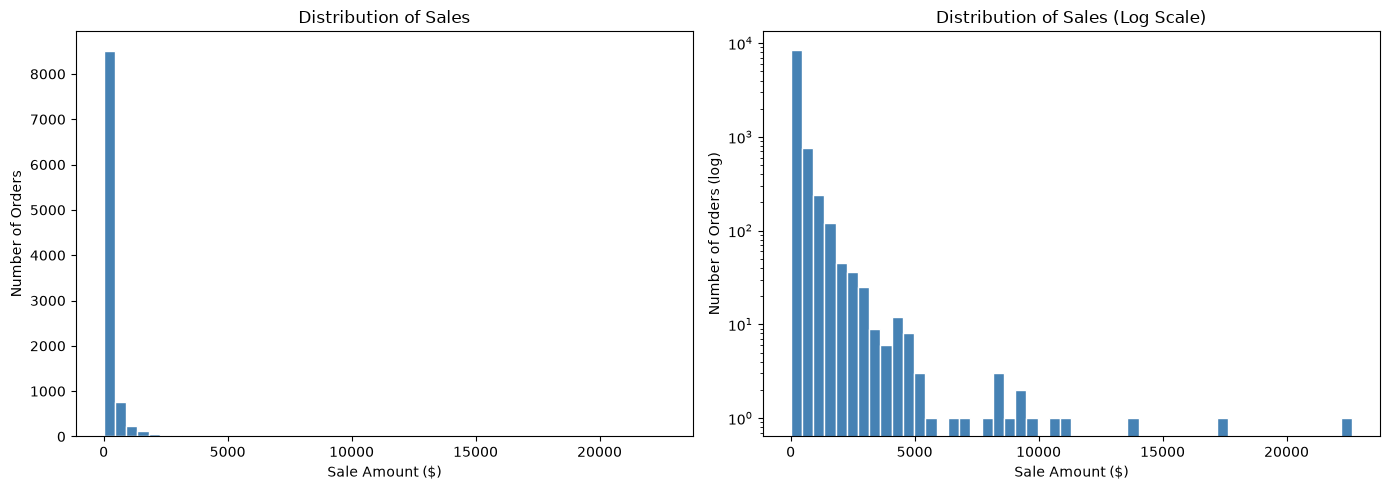

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of sales
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sale Amount ($)')
axes[0].set_ylabel('Number of Orders')

# Log scale to see the full picture
axes[1].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white', log=True)
axes[1].set_title('Distribution of Sales (Log Scale)')
axes[1].set_xlabel('Sale Amount ($)')
axes[1].set_ylabel('Number of Orders (log)')

plt.tight_layout()
plt.savefig('../data/processed/sales_distribution.png', dpi=150)
plt.show()

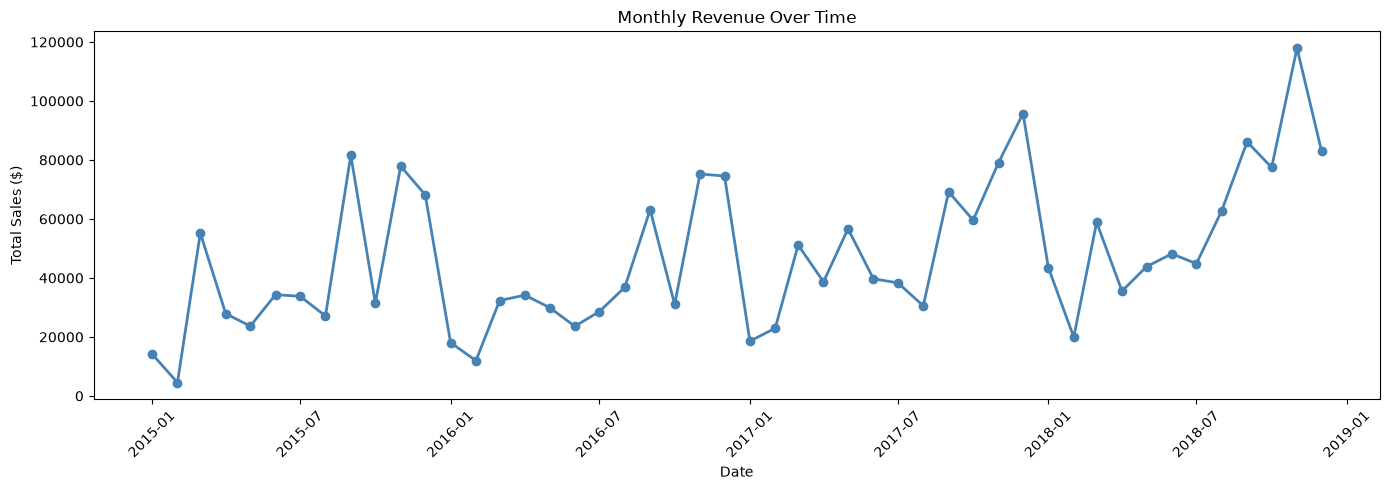

    order_year  order_month        Sales       date
0         2015            1   14205.7070 2015-01-01
1         2015            2    4519.8920 2015-02-01
2         2015            3   55205.7970 2015-03-01
3         2015            4   27906.8550 2015-04-01
4         2015            5   23644.3030 2015-05-01
5         2015            6   34322.9356 2015-06-01
6         2015            7   33781.5430 2015-07-01
7         2015            8   27117.5365 2015-08-01
8         2015            9   81623.5268 2015-09-01
9         2015           10   31453.3930 2015-10-01
10        2015           11   77907.6607 2015-11-01
11        2015           12   68167.0585 2015-12-01
12        2016            1   18066.9576 2016-01-01
13        2016            2   11951.4110 2016-02-01
14        2016            3   32339.3184 2016-03-01
15        2016            4   34154.4685 2016-04-01
16        2016            5   29959.5305 2016-05-01
17        2016            6   23599.3740 2016-06-01
18        20

In [9]:
# Revenue over time - monthly
monthly_revenue = df.groupby(['order_year', 'order_month'])['Sales'].sum().reset_index()
monthly_revenue['date'] = pd.to_datetime({
    'year': monthly_revenue['order_year'],
    'month': monthly_revenue['order_month'],
    'day': 1
})
monthly_revenue = monthly_revenue.sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['date'], monthly_revenue['Sales'], 
         marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/monthly_revenue.png', dpi=150)
plt.show()

print(monthly_revenue)

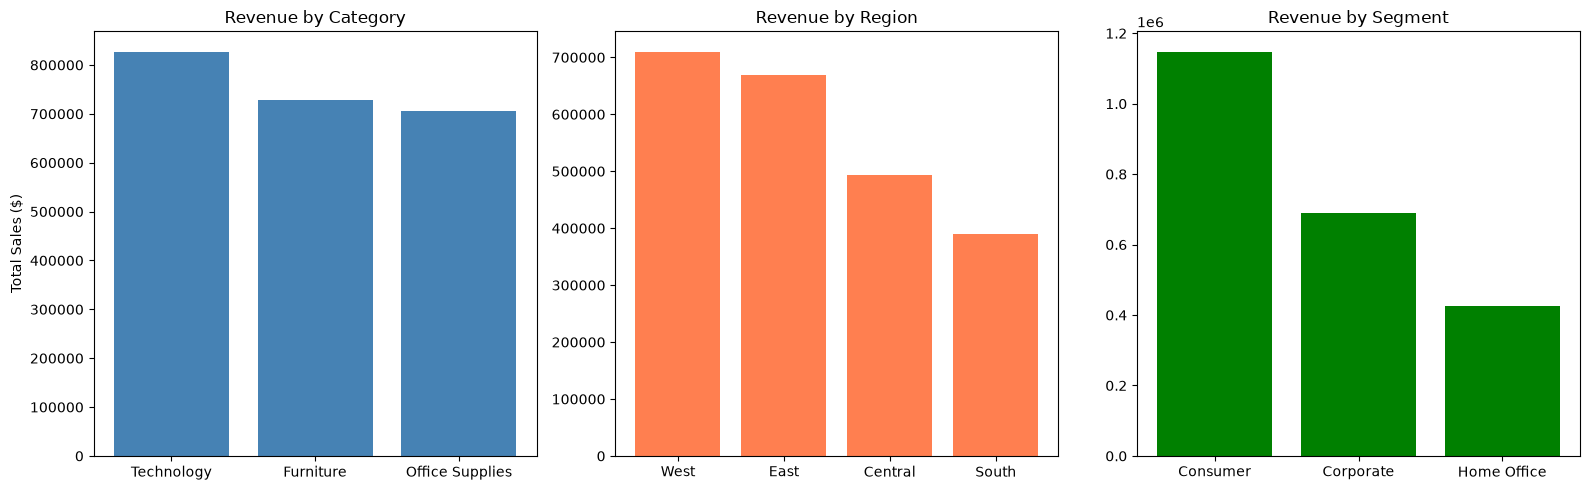

Category:
           Category        Sales
0       Technology  827455.8730
1        Furniture  728658.5757
2  Office Supplies  705422.3340

Region:
     Region        Sales
0     West  710219.6845
1     East  669518.7260
2  Central  492646.9132
3    South  389151.4590

Segment:
        Segment         Sales
0     Consumer  1.148061e+06
1    Corporate  6.884941e+05
2  Home Office  4.249822e+05


In [10]:
# Revenue by Category
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

# Revenue by Region
region_revenue = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

# Revenue by Segment
segment_revenue = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(category_revenue['Category'], category_revenue['Sales'], color='steelblue')
axes[0].set_title('Revenue by Category')
axes[0].set_ylabel('Total Sales ($)')

axes[1].bar(region_revenue['Region'], region_revenue['Sales'], color='coral')
axes[1].set_title('Revenue by Region')

axes[2].bar(segment_revenue['Segment'], segment_revenue['Sales'], color='green')
axes[2].set_title('Revenue by Segment')

plt.tight_layout()
plt.savefig('../data/processed/revenue_breakdown.png', dpi=150)
plt.show()

print("Category:\n", category_revenue)
print("\nRegion:\n", region_revenue)
print("\nSegment:\n", segment_revenue)

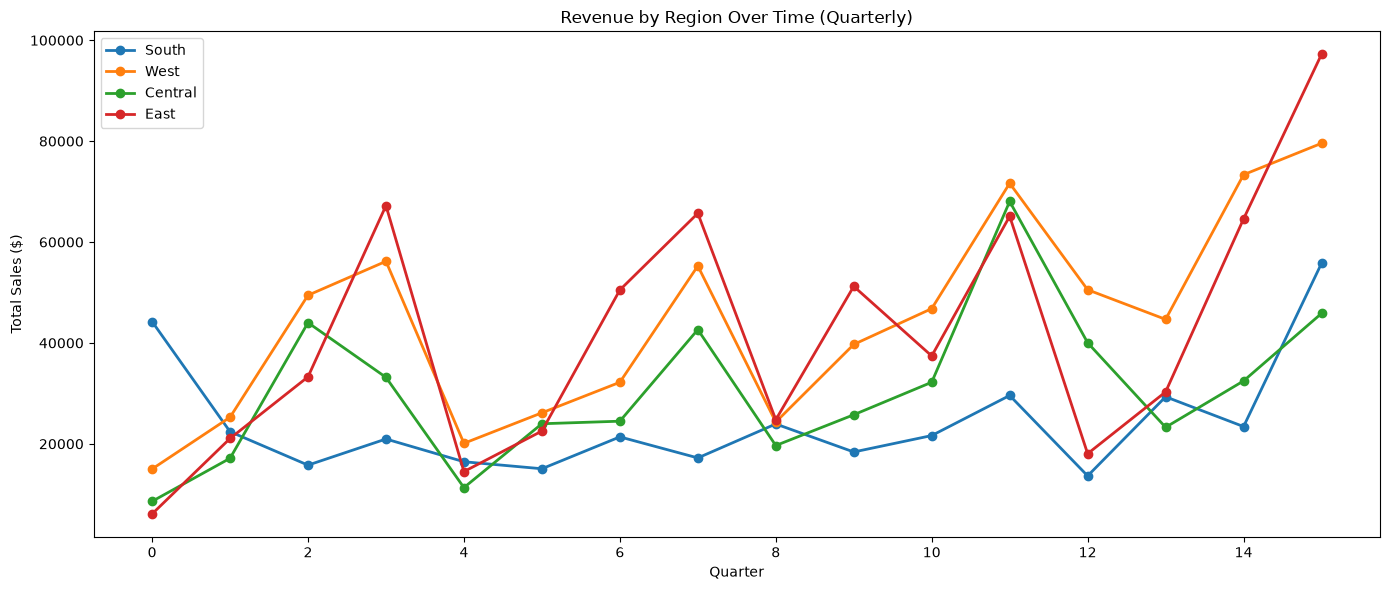

In [11]:
# Revenue by region over time
region_time = df.groupby(['order_year', 'order_quarter', 'Region'])['Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
for region in df['Region'].unique():
    data = region_time[region_time['Region'] == region]
    label_x = data.index
    plt.plot(range(len(data)), data['Sales'], marker='o', label=region, linewidth=2)

plt.title('Revenue by Region Over Time (Quarterly)')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/region_over_time.png', dpi=150)
plt.show()

In [13]:
customer_count = df.groupby('order_year')['Customer ID'].nunique().reset_index()
customer_count.columns = ['year', 'unique_customers']
print(customer_count)

   year  unique_customers
0  2015               589
1  2016               567
2  2017               635
3  2018               690


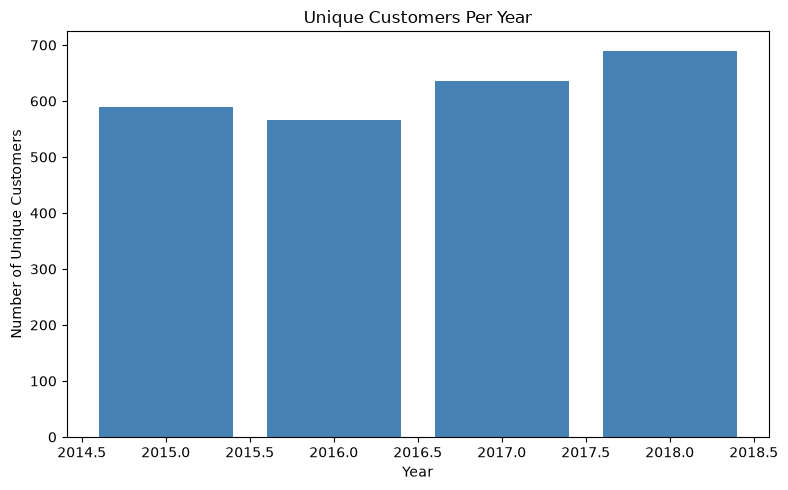

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(customer_count['year'], customer_count['unique_customers'], color='steelblue')
plt.title('Unique Customers Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.savefig('../data/processed/customer_count.png', dpi=150)
plt.show()